En este nootbook el objetivo es unir tablas y entender el problema que se nos pantea

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.style.use("ggplot")


Primero descargamos los archivos en la carperta data/

In [ ]:
import boto3
import os

s3 = boto3.client(
    's3',
    aws_access_key_id='' #hay que borrarlo
    aws_secret_access_key='' #hay que borrarlo
) 

bucket_name = 'zrive-ds-data'

files = {
    'groceries/sampled-datasets/orders.parquet': '../data/orders.parquet',
    'groceries/sampled-datasets/regulars.parquet': '../data/regulars.parquet',
    'groceries/sampled-datasets/abandoned_carts.parquet': '../data/abandoned_cart.parquet',
    'groceries/sampled-datasets/inventory.parquet': '../data/inventory.parquet',
    'groceries/sampled-datasets/users.parquet': '../data/users.parquet',
}

# Crear la carpeta data si no existe
if not os.path.exists('../data'):
    os.makedirs('../data')
    print("Carpeta 'data' creada con éxito.")

for s3_path, local_path in files.items():
    if not os.path.exists(local_path):
        try:
            print(f"Descargando {s3_path}...")
            s3.download_file(bucket_name, s3_path, local_path)
            print(f"{local_path} descargado.")
        except Exception as e:
            print(f"Error con {s3_path}: {e}")
    else:
        print(f"{local_path} ya está listo.")

../data/orders.parquet ya está listo.
../data/regulars.parquet ya está listo.
../data/abandoned_cart.parquet ya está listo.
../data/inventory.parquet ya está listo.
../data/users.parquet ya está listo.


# Understanding the problem

In [4]:
# Cargar datos
orders = pd.read_parquet('../data/orders.parquet')
orders.info()


<class 'pandas.core.frame.DataFrame'>
Index: 8773 entries, 10 to 64538
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              8773 non-null   int64         
 1   user_id         8773 non-null   object        
 2   created_at      8773 non-null   datetime64[us]
 3   order_date      8773 non-null   datetime64[us]
 4   user_order_seq  8773 non-null   int64         
 5   ordered_items   8773 non-null   object        
dtypes: datetime64[us](2), int64(2), object(2)
memory usage: 479.8+ KB


In [5]:
orders.head()

,id,user_id,created_at,order_date,user_order_seq,ordered_items
10,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,2020-04-30,1,"[33618849693828, 33618860179588, 3361887404045..."
20,2204707520644,bf591c887c46d5d3513142b6a855dd7ffb9cc00697f6f5...,2020-04-30 17:39:00,2020-04-30,1,"[33618835243140, 33618835964036, 3361886244058..."
21,2204838822020,329f08c66abb51f8c0b8a9526670da2d94c0c6eef06700...,2020-04-30 18:12:30,2020-04-30,1,"[33618891145348, 33618893570180, 3361889766618..."
34,2208967852164,f6451fce7b1c58d0effbe37fcb4e67b718193562766470...,2020-05-01 19:44:11,2020-05-01,1,"[33618830196868, 33618846580868, 3361891234624..."
49,2215889436804,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,2020-05-03 21:56:14,2020-05-03,1,"[33667166699652, 33667166699652, 3366717122163..."


In [6]:
orders.describe()

,id,created_at,order_date,user_order_seq
count,8.773000e+03,8773,8773,8773.000000
mean,3.684684e+12,2021-08-22 03:54:18.750028,2021-08-21 12:47:21.262966,2.445116
min,2.204073e+12,2020-04-30 14:32:19,2020-04-30 00:00:00,1.000000
25%,3.690255e+12,2021-04-25 11:50:37,2021-04-25 00:00:00,1.000000
50%,3.846692e+12,2021-10-11 11:29:44,2021-10-11 00:00:00,1.000000
75%,3.945086e+12,2022-01-03 18:14:23,2022-01-03 00:00:00,3.000000
max,4.026732e+12,2022-03-14 00:24:59,2022-03-14 00:00:00,25.000000
std,4.145437e+11,NaN,NaN,2.707693


In [7]:
inventory = pd.read_parquet('../data/inventory.parquet')
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1733 entries, 0 to 1732
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   variant_id        1733 non-null   int64  
 1   price             1733 non-null   float64
 2   compare_at_price  1733 non-null   float64
 3   vendor            1733 non-null   object 
 4   product_type      1733 non-null   object 
 5   tags              1733 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 81.4+ KB


In [8]:
inventory.tail()

,variant_id,price,compare_at_price,vendor,product_type,tags
1728,39539419218052,4.99,5.99,bother,,[household-sundries]
1729,34534187368580,4.69,5.49,tommeetippee,baby-accessories,[feeding-weaning]
1730,33826439594116,15.39,17.15,colief,baby-accessories,[feeding-weaning]
1731,33667214508164,19.49,21.65,enterosgel,medicines-treatments,"[discontinue, first-aid]"
1732,33667214704772,31.99,34.60,eskimo3,superfoods-supplements,"[discontinue, vitamins-supplements]"


In [9]:
users=pd.read_parquet('../data/users.parquet')
users.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4983 entries, 2160 to 3360
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                4983 non-null   object 
 1   user_segment           4983 non-null   object 
 2   user_nuts1             4932 non-null   object 
 3   first_ordered_at       4983 non-null   object 
 4   customer_cohort_month  4983 non-null   object 
 5   count_people           325 non-null    float64
 6   count_adults           325 non-null    float64
 7   count_children         325 non-null    float64
 8   count_babies           325 non-null    float64
 9   count_pets             325 non-null    float64
dtypes: float64(5), object(5)
memory usage: 428.2+ KB


In [10]:
users.dropna().head()

,user_id,user_segment,user_nuts1,first_ordered_at,customer_cohort_month,count_people,count_adults,count_children,count_babies,count_pets
4751,09d70e0b0778117aec5550c08032d56f8e06f992741680...,Proposition,UKI,2021-06-28 12:07:04,2021-06-01 00:00:00,1.0,1.0,0.0,0.0,0.0
3154,4f5ff38ce5ed48096ba80dff80e167db1ad24b9ebdb00c...,Top Up,UKD,2020-06-12 12:07:35,2020-06-01 00:00:00,3.0,2.0,0.0,1.0,0.0
736,7b2ae50bb11646436fa613394fc3e71e1a0cdc3ba30cdb...,Proposition,UKF,2020-10-03 09:53:57,2020-10-01 00:00:00,2.0,2.0,0.0,0.0,2.0
4792,5e977a4aa2c57f306b8a22f92eaaa177f7dc31a52df82c...,Proposition,UKI,2021-10-14 10:41:13,2021-10-01 00:00:00,2.0,1.0,1.0,0.0,1.0
2217,eafb89ad33eb377adb98a915b6a5a65f1284c2db517d07...,Proposition,UKH,2022-01-20 15:53:09,2022-01-01 00:00:00,2.0,2.0,0.0,0.0,0.0


In [11]:
users.isna().sum()

user_id                     0
user_segment                0
user_nuts1                 51
first_ordered_at            0
customer_cohort_month       0
count_people             4658
count_adults             4658
count_children           4658
count_babies             4658
count_pets               4658
dtype: int64

In [12]:
regulars = pd.read_parquet('../data/regulars.parquet')
regulars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18105 entries, 3 to 37720
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     18105 non-null  object        
 1   variant_id  18105 non-null  int64         
 2   created_at  18105 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(1), object(1)
memory usage: 565.8+ KB


In [13]:
regulars.tail()

,user_id,variant_id,created_at
37644,20a41b8fa616484b39812aaa377ea1b53247f6941c0586...,39265878999172,2022-03-13 16:02:13
37717,ba068a3398230c10a98868ced1fcc5b889b21e6f112fd0...,39459281272964,2022-03-14 07:49:24
37718,ba068a3398230c10a98868ced1fcc5b889b21e6f112fd0...,33973246951556,2022-03-14 07:49:24
37719,ba068a3398230c10a98868ced1fcc5b889b21e6f112fd0...,39587297656964,2022-03-14 07:49:24
37720,ba068a3398230c10a98868ced1fcc5b889b21e6f112fd0...,34415987753092,2022-03-14 07:49:24


In [14]:
abandoned = pd.read_parquet('../data/abandoned_cart.parquet')
abandoned.info()


<class 'pandas.core.frame.DataFrame'>
Index: 5457 entries, 0 to 70050
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          5457 non-null   int64         
 1   user_id     5457 non-null   object        
 2   created_at  5457 non-null   datetime64[us]
 3   variant_id  5457 non-null   object        
dtypes: datetime64[us](1), int64(1), object(2)
memory usage: 213.2+ KB


In [15]:
print("Muestra de carritos abandonados:")
display(abandoned.head())

Muestra de carritos abandonados:


,id,user_id,created_at,variant_id
0,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,"[33826459287684, 33826457616516, 3366719212762..."
13,20352449839236,9d6187545c005d39e44d0456d87790db18611d7c7379bd...,2021-06-27 05:24:13,"[34415988179076, 34037940158596, 3450282236326..."
45,20478401413252,e83fb0273d70c37a2968fee107113698fd4f389c442c0b...,2021-07-18 08:23:49,"[34543001337988, 34037939372164, 3411360609088..."
50,20481783103620,10c42e10e530284b7c7c50f3a23a98726d5747b8128084...,2021-07-18 21:29:36,"[33667268116612, 34037940224132, 3443605520397..."
52,20485321687172,d9989439524b3f6fc4f41686d043f315fb408b954d6153...,2021-07-19 12:17:05,"[33667268083844, 34284950454404, 33973246886020]"


Quick Checks hechos y todo correcto.

Potential Issues: 
* lista de productos en ordenes dentro de columnas que pueden hacer complicada la comprension de las ordenes y los abandones en caso de querer ir producto a producto
* Hay missing values en Users

# Análisis
Recomendado separar el analisi en objetivos/fases:
1. Perfilar usuarios
2. Restructurar orders
3. Productos abandonados


## Perfilar usuarios

In [16]:
# juntamos n_regulars to users profile
n_regulars = (
    regulars.groupby("user_id")["variant_id"] #agrupa regulares a traves de users
    .nunique() # cuenta los productos distintos por cada usuario 
    .reset_index() # convierte el resultado en un DF no indeado por user_id
    .rename(columns={"variant_id": "n_regulars"})
)

users = users.merge(n_regulars, on="user_id", how="left").fillna({"n_regulars": 0}) # con el fillna a los que no tengan regulars les pone un 0

In [17]:
n_regulars.head()

,user_id,n_regulars
0,004b3e3cb9a9f5b0974ce4179db394057c72e7a82077bf...,1
1,005743eefffa4ce840608c4f47b8c548b134d89be5c390...,2
2,0074992079c1836c6509eec748a973dc97388b4877e770...,24
3,00ecced73edb11d4bab08e794656dcf9d9b89ea89c5918...,3
4,014301579c18e7c7f034e544ab3d4ee235ef2de43ee5db...,5


In [18]:
users.dropna().head()

,user_id,user_segment,user_nuts1,first_ordered_at,customer_cohort_month,count_people,count_adults,count_children,count_babies,count_pets,n_regulars
23,09d70e0b0778117aec5550c08032d56f8e06f992741680...,Proposition,UKI,2021-06-28 12:07:04,2021-06-01 00:00:00,1.0,1.0,0.0,0.0,0.0,0.0
27,4f5ff38ce5ed48096ba80dff80e167db1ad24b9ebdb00c...,Top Up,UKD,2020-06-12 12:07:35,2020-06-01 00:00:00,3.0,2.0,0.0,1.0,0.0,1.0
28,7b2ae50bb11646436fa613394fc3e71e1a0cdc3ba30cdb...,Proposition,UKF,2020-10-03 09:53:57,2020-10-01 00:00:00,2.0,2.0,0.0,0.0,2.0,25.0
35,5e977a4aa2c57f306b8a22f92eaaa177f7dc31a52df82c...,Proposition,UKI,2021-10-14 10:41:13,2021-10-01 00:00:00,2.0,1.0,1.0,0.0,1.0,72.0
66,eafb89ad33eb377adb98a915b6a5a65f1284c2db517d07...,Proposition,UKH,2022-01-20 15:53:09,2022-01-01 00:00:00,2.0,2.0,0.0,0.0,0.0,3.0


In [19]:
users.describe()

,count_people,count_adults,count_children,count_babies,count_pets,n_regulars
count,325.000000,325.000000,325.000000,325.000000,325.000000,4983.000000
mean,2.787692,2.003077,0.707692,0.076923,0.636923,2.481437
std,1.365753,0.869577,1.026246,0.289086,0.995603,8.890588
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000
75%,4.000000,2.000000,1.000000,0.000000,1.000000,1.000000
max,8.000000,7.000000,6.000000,2.000000,6.000000,320.000000


El 75% tiene 1 producto regular o 0. Pero posible outliers 320 productos regulares

Text(0.5, 1.0, 'Distribución de adultos por nucleo familiar ')

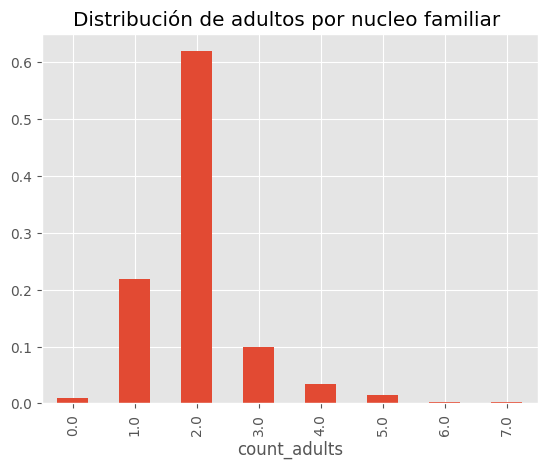

In [20]:
# En la columne count_adults cuenta cuantas veces aparece cada valor (de forma porcentual)
# la funcion sort_index ordena por el valor del indice

users.count_adults.value_counts(normalize=True).sort_index().plot(kind="bar")
plt.title("Distribución de adultos por nucleo familiar ")

In [21]:
# de users nos quedamos los que n_regulars sea menor a 100
users.loc[lambda x: x.n_regulars < 50].n_regulars.describe()

count    4956.000000
mean        2.076877
std         5.967786
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        49.000000
Name: n_regulars, dtype: float64

In [22]:
(users["n_regulars"] > 10).sum() / len(users)

0.07264699979931769

In [23]:
(users["n_regulars"] == 0).sum() / len(users)

0.7094120008027293

In [24]:
(users["user_segment"] == "Top Up").sum() / users["user_id"].count()

0.5304033714629741

In [25]:
(users["user_segment"] == "Proposition").sum() / users["user_id"].count()

0.4695966285370259

<Axes: xlabel='user_nuts1'>

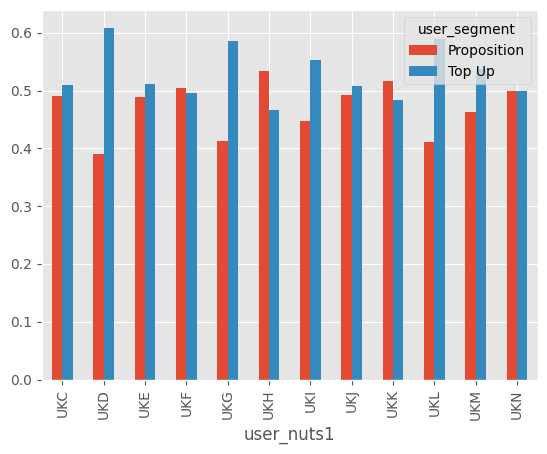

In [26]:
# pd.crosstab(fila, columna)
pd.crosstab(users["user_nuts1"], users["user_segment"], normalize="index").plot(kind="bar")

### Insights:
1. El 75% tiene 1 producto regular o 0. Pero hay posibles outliers de clientes con 320 productos regulares
2. Los clientes como norma general son adultos sin bebes o sin hijos ni mascotas, o pocos.
3. El promedio es de 2 adulto por bloque familiar
4. El 70% de clientes no marca prodcutos como regulares
5. Dos grandes grupos de usuarios os Top up y los Proposition (53% y 47%)
6. Els dos segmentes semblan equitativament distribuits geograficament, on hi ha més desquilibri 


## Restructurar orders

In [27]:
# Ver el problema: ordered_items es una lista
print("Muestra de pedidos y sus listas de productos:")
display(orders[['id', 'ordered_items']].head())

# Paso clave: 'Explotar' la lista para tener una fila por producto
# Esto crea una fila por cada producto, manteniendo el mismo 'id' de pedido.
orders_exploded = orders.explode('ordered_items')

# 3. Renombrar para que sea más claro (opcional pero recomendado)
orders_exploded = orders_exploded.rename(columns={'ordered_items': 'item_id'})

print("\nEstructura 'explotada' (lista para unir con inventario):")
display(orders_exploded[['id', 'item_id']].head())

Muestra de pedidos y sus listas de productos:


,id,ordered_items
10,2204073066628,"[33618849693828, 33618860179588, 3361887404045..."
20,2204707520644,"[33618835243140, 33618835964036, 3361886244058..."
21,2204838822020,"[33618891145348, 33618893570180, 3361889766618..."
34,2208967852164,"[33618830196868, 33618846580868, 3361891234624..."
49,2215889436804,"[33667166699652, 33667166699652, 3366717122163..."



Estructura 'explotada' (lista para unir con inventario):


,id,item_id
10,2204073066628,33618849693828
10,2204073066628,33618860179588
10,2204073066628,33618874040452
10,2204073066628,33618907005060
10,2204073066628,33618907005060


In [28]:
# Unimos los pedidos ya explotados con la información del catálogo
# Hacemos un join entre los productos que se han ordenado y la tabla de inventarry donde sale la info del producto
# Usamos left_on y right_on porque las columnas se llaman distinto en cada tabla
df_pedidos_detallados = orders_exploded.merge(
    inventory, 
    left_on='item_id', # ID que viene de los pedidos o de las orders
    right_on='variant_id', # ID real del inventory
    how='left' # Mantén todos los pedidos aunque no encuentres info en inventario.
)

# Limpiamos un poco para no tener columnas repetidas
if 'id_x' in df_pedidos_detallados.columns:
    df_pedidos_detallados = df_pedidos_detallados.rename(columns={'id_x': 'order_id'})

print("--- TOP 5 PRODUCTOS COMPRADOS ---")
display(df_pedidos_detallados['product_type'].value_counts().head(5))

# vamos a ver las marcs más populares
print("\n--- TOP 5 VENDORS (MARCAS) ---")
display(df_pedidos_detallados['vendor'].value_counts().head(5))


--- TOP 5 PRODUCTOS COMPRADOS ---


product_type
cleaning-products                  9676
tins-packaged-foods                8959
long-life-milk-substitutes         6637
toilet-roll-kitchen-roll-tissue    6314
dishwashing                        4362
Name: count, dtype: int64


--- TOP 5 VENDORS (MARCAS) ---


vendor
oatly     5345
ecover    3445
method    3293
fairy     3188
biona     2184
Name: count, dtype: int64

In [46]:
print("--- TOP 5 PRODUCTOS Menos COMPRADOS ---")
display(df_pedidos_detallados['product_type'].value_counts().tail(5))

print("\n--- TOP 5 peores VENDORS (MARCAS) ---")
display(df_pedidos_detallados['vendor'].value_counts().tail(5))


--- TOP 5 PRODUCTOS Menos COMPRADOS ---


product_type
adult-incontinence     39
suncare                38
premixed-cocktails     29
medicine-treatments    27
mixed-bundles           2
Name: count, dtype: int64


--- TOP 5 peores VENDORS (MARCAS) ---


vendor
gordans           1
seedlip           1
sudafed           1
enterosgel        1
stlawrencegold    1
Name: count, dtype: int64

Con esto tenemos los pedidos detallados por poductos.
Ahora vamos a ver si hay datos fantasma y si es significativo.

In [29]:
# ¿Hay productos en los pedidos que no existen en el inventario?
productos_fantasma = df_pedidos_detallados['product_type'].isna().sum() # isna nos convierte en true si falta el dato y falso si no
porcentaje_error = (productos_fantasma / len(df_pedidos_detallados)) * 100

print(f"Productos sin información de inventario: {productos_fantasma} ({porcentaje_error:.2f}%)")

Productos sin información de inventario: 15597 (14.45%)


### Insights:
1. Mucha diferencoa entre los productos más vendidos, que son productos de limpiez, con los menos vendidos que son los paquetes mixtos y los medicmentos.
2. El 14,45% es un porcentage significativo que se deberias solucionar. Esto podría responder a productos que la gente pide pero no estan en el catalogo asi que una opcion razonable podría ser eliminarlos. Podría ser también que se deba a una falta de stock actual en ese caso quizas se trata de informacion relevante. Una posible solucion podria ser reyenar la informacion incompleta con la que tenemos de DataSet de productos pedidos. 


## Estudiar los productos abandonados

In [30]:
#vamos a ver ahora que productos son abandonados
#para eso vamos a explotar los abandonos de productos
abandoned_exploded = abandoned.explode('variant_id')

print("\nEstructura 'explotada' (lista para unir con inventario):")
display(abandoned_exploded[['id', 'variant_id']].head())


Estructura 'explotada' (lista para unir con inventario):


,id,variant_id
0,12858560217220,33826459287684
0,12858560217220,33826457616516
0,12858560217220,33667192127620
0,12858560217220,33826412331140
0,12858560217220,33826472558724


In [31]:
# ahora unimos los pedidos abandonados con el catalogo
df_pedidos_abandonados= abandoned_exploded.merge(
    inventory, 
    on="variant_id",
    how='left' # Mantén todos los pedidos aunque no encuentres info en inventario.
)

# Limpiamos un poco para no tener columnas repetidas
if 'id_x' in df_pedidos_abandonados.columns:
    df_pedidos_abandonados = df_pedidos_abandonados.rename(columns={'id_x': 'order_id'})

print("--- TOP 5 PRODUCTOS ABANDONADOS ---")
display(df_pedidos_abandonados['product_type'].value_counts().head(5))

# vamos a ver las marcs más populares
print("\n--- TOP 5 CREATED_AT (MARCAS) ---")
display(df_pedidos_abandonados['vendor'].value_counts().head(5))


--- TOP 5 PRODUCTOS ABANDONADOS ---


product_type
tins-packaged-foods                2700
cleaning-products                  2525
toilet-roll-kitchen-roll-tissue    2257
soft-drinks-mixers                 1769
dishwashing                        1694
Name: count, dtype: int64


--- TOP 5 CREATED_AT (MARCAS) ---


vendor
fairy       1505
ecover       925
napolina     909
andrex       841
oatly        785
Name: count, dtype: int64

In [32]:
display(df_pedidos_abandonados)


,id,user_id,created_at,variant_id,price,compare_at_price,vendor,product_type,tags
0,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826459287684,NaN,NaN,NaN,NaN,NaN
1,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826457616516,NaN,NaN,NaN,NaN,NaN
2,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33667192127620,NaN,NaN,NaN,NaN,NaN
3,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826412331140,NaN,NaN,NaN,NaN,NaN
4,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,33826472558724,3.99,4.09,profusion,cooking-ingredients,"[salt-pepper, vegan]"
...,...,...,...,...,...,...,...,...,...
30864,22233846218884,a4da55d51052411e54f98e1b90b19843121866abeaea76...,2022-03-13 14:12:09,39482337624196,15.99,18.00,surf,washing-powder,[washing-powder]
30865,22233846218884,a4da55d51052411e54f98e1b90b19843121866abeaea76...,2022-03-13 14:12:09,39607712153732,8.99,12.00,comfort,fabric-softener-freshener,"[fabric-softener-freshener, refills]"
30866,22233846317188,c0e740ecabe7bd19eaed35b5ea9be7bc80c15f32124712...,2022-03-13 14:12:10,34284950519940,9.99,12.00,fairy,dishwashing,[dishwasher-tablets]
30867,22233846317188,c0e740ecabe7bd19eaed35b5ea9be7bc80c15f32124712...,2022-03-13 14:12:10,39459281174660,2.99,4.47,carex,hand-soap-sanitisers,"[eco, hand-soap]"


In [47]:
df_pedidos_abandonados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30869 entries, 0 to 30868
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                30869 non-null  int64         
 1   user_id           30869 non-null  object        
 2   created_at        30869 non-null  datetime64[us]
 3   variant_id        30869 non-null  object        
 4   price             29328 non-null  float64       
 5   compare_at_price  29328 non-null  float64       
 6   vendor            29328 non-null  object        
 7   product_type      29328 non-null  object        
 8   tags              29328 non-null  object        
dtypes: datetime64[us](1), float64(2), int64(1), object(5)
memory usage: 2.1+ MB


In [48]:
missing_price = df_pedidos_abandonados['price'].isna().sum() # isna nos convierte en true si falta el dato y falso si no
porcentaje_error = (missing_price / len(df_pedidos_abandonados)) * 100

print(f"Productos sin información de precio: {missing_price} ({porcentaje_error:.2f}%)")

Productos sin información de precio: 1541 (4.99%)


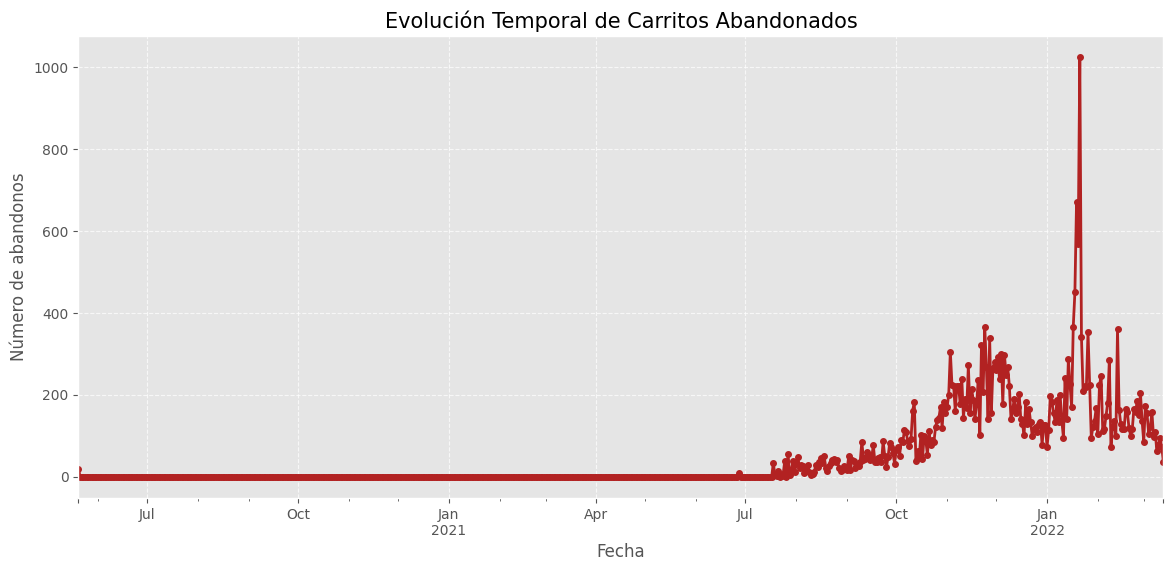

In [33]:
# 1. Aseguramos el formato de fecha
df_pedidos_abandonados['created_at'] = pd.to_datetime(df_pedidos_abandonados['created_at'])

# 2.usamos 'user_id' para contar los abandonos diarios
abandonos_temporales = df_pedidos_abandonados.set_index('created_at').resample('D')['user_id'].count()

# 3. Visualización
plt.figure(figsize=(14, 6))
abandonos_temporales.plot(kind='line', color='firebrick', linewidth=2, marker='o', markersize=4)

plt.title('Evolución Temporal de Carritos Abandonados', fontsize=15)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Número de abandonos', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Insights:
1. Los productos que más se abandonan en el carrito son tins-packaged-foods y cleaning-products, justo uno de los que más se piden
2. Lo mismo pasa con marcas como fairy y oatly 
3. hay missing values en precios, compare_at_price, vendor, product_type y tags. Aproximadamente de un 4,99% de MV en prices que podria ser preocupante. Porque faltan esos valores?
4. Dos pics relevantes en productos abandonados en Noviemre-Diciembre, y el más acentuado en enero. Esto podrai deberese a que la mayoria de datos que se hayan recogido sean principalmente en ese periodo o podría haber alguna causalidad. 
5. Posible outlier en enero con más de 1000 abandonos, mientras que de media ronda los 200 abandonos.(al día)

# EDA

In [34]:
# Listar objetos para encontrar la ruta correcta
response = s3.list_objects_v2(Bucket='zrive-ds-data', Prefix='groceries/')

print("Archivos encontrados en el servidor:")
for obj in response.get('Contents', []):
    print(obj['Key'])

Archivos encontrados en el servidor:
groceries/box_builder_dataset/feature_frame.csv
groceries/sampled-datasets/abandoned_carts.parquet
groceries/sampled-datasets/inventory.parquet
groceries/sampled-datasets/orders.parquet
groceries/sampled-datasets/regulars.parquet
groceries/sampled-datasets/users.parquet
groceries/trained-models/model.joblib


In [35]:
# Definimos la ruta del archivo que falta
s3_path_box = 'groceries/box_builder_dataset/feature_frame.csv'
local_path_box = '../data/sampled_box_builder_df.csv'

try:
    if not os.path.exists(local_path_box):
        print(f"Descargando {s3_path_box}...")
        s3.download_file(bucket_name, s3_path_box, local_path_box)
        print(f" {local_path_box} descargado con éxito.")
    else:
        print(f" {local_path_box} ya existe en tu carpeta data.")
except Exception as e:
    print(f" Error al descargar: {e}")

 ../data/sampled_box_builder_df.csv ya existe en tu carpeta data.


In [36]:
df_box = pd.read_csv('../data/sampled_box_builder_df.csv')

In [37]:
df_box.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2880549 entries, 0 to 2880548
Data columns (total 27 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   variant_id                        int64  
 1   product_type                      object 
 2   order_id                          int64  
 3   user_id                           int64  
 4   created_at                        object 
 5   order_date                        object 
 6   user_order_seq                    int64  
 7   outcome                           float64
 8   ordered_before                    float64
 9   abandoned_before                  float64
 10  active_snoozed                    float64
 11  set_as_regular                    float64
 12  normalised_price                  float64
 13  discount_pct                      float64
 14  vendor                            object 
 15  global_popularity                 float64
 16  count_adults                      fl

In [38]:
df_box.head()

,variant_id,product_type,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
0,33826472919172,ricepastapulses,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
1,33826472919172,ricepastapulses,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
2,33826472919172,ricepastapulses,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05 00:00:00,4,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
3,33826472919172,ricepastapulses,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
4,33826472919172,ricepastapulses,2808429314180,3537167515780,2020-10-06 10:37:05,2020-10-06 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618


In [39]:
df_box.describe()

,variant_id,order_id,user_id,user_order_seq,outcome,ordered_before,abandoned_before,active_snoozed,set_as_regular,normalised_price,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
count,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,...,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06
mean,3.401250e+13,2.978388e+12,3.750025e+12,3.289342e+00,1.153669e-02,2.113868e-02,6.092589e-04,2.290188e-03,3.629864e-03,1.272808e-01,...,5.492182e-02,3.538562e-03,5.134091e-02,2.072549e+00,3.312961e+01,3.523734e+01,2.645304e+01,3.143513e+01,3.088810e+01,2.594969e+01
std,2.786246e+11,2.446292e+11,1.775710e+11,2.140176e+00,1.067876e-01,1.438466e-01,2.467565e-02,4.780109e-02,6.013891e-02,1.268378e-01,...,3.276586e-01,5.938048e-02,3.013646e-01,3.943659e-01,3.707162e+00,1.057766e+01,7.168323e+00,1.227511e+01,4.330262e+00,3.278860e+00
min,3.361529e+13,2.807986e+12,3.046041e+12,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.599349e-02,...,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.414214e+00,0.000000e+00,7.000000e+00,2.828427e+00
25%,3.380354e+13,2.875152e+12,3.745901e+12,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.394416e-02,...,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,3.300000e+01,3.000000e+01,2.319372e+01,3.000000e+01,2.800000e+01,2.427618e+01
50%,3.397325e+13,2.902856e+12,3.812775e+12,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.105178e-02,...,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,3.300000e+01,3.400000e+01,2.769305e+01,3.000000e+01,3.100000e+01,2.608188e+01
75%,3.428495e+13,2.922034e+12,3.874925e+12,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.352670e-01,...,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,3.300000e+01,4.000000e+01,3.059484e+01,3.000000e+01,3.400000e+01,2.796118e+01
max,3.454300e+13,3.643302e+12,5.029635e+12,2.100000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,3.000000e+00,1.000000e+00,6.000000e+00,5.000000e+00,1.480000e+02,8.400000e+01,5.868986e+01,1.480000e+02,3.950000e+01,3.564191e+01


In [40]:
df_box['outcome'].value_counts(normalize=True)

outcome
0.0    0.988463
1.0    0.011537
Name: proportion, dtype: float64

Solo el $1.1537\%$ de las filas son casos de éxito ($outcome = 1$), mientras que el $98.8463\%$ son casos donde no hubo compra ($outcome = 0$)

In [41]:
# Filtramos solo las columnas numéricas para evitar el ValueError
df_numeric = df_box.select_dtypes(include=['number'])

# Ver la correlación de todas las variables con el objetivo
correlaciones = df_numeric.corr()['outcome'].sort_values(ascending=False)

print("Correlación de las variables con el éxito (outcome):")
print(correlaciones.head(10))

Correlación de las variables con el éxito (outcome):
outcome                             1.000000
ordered_before                      0.211139
abandoned_before                    0.163332
global_popularity                   0.162628
set_as_regular                      0.134621
active_snoozed                      0.045763
days_since_purchase_variant_id      0.022814
variant_id                          0.017823
days_since_purchase_product_type    0.010520
user_order_seq                      0.010177
Name: outcome, dtype: float64


No se detecta ninguna variable con correlacion destacable con la tasa de exito 

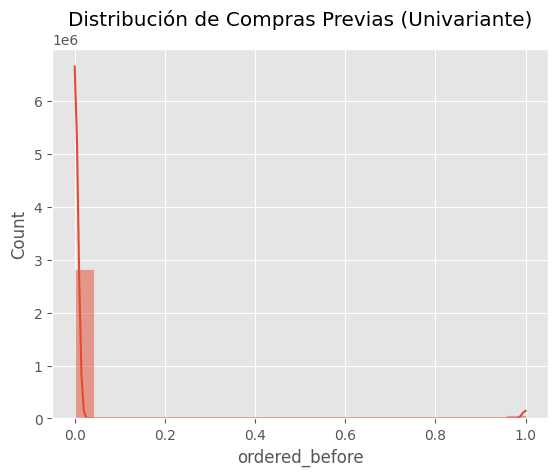

In [42]:
# Histograma para ver la distribución de compras previas [cite: 11]
sns.histplot(df_box['ordered_before'], kde=True)
plt.title('Distribución de Compras Previas (Univariante)')
plt.show()

La mayoria de usuarios en este dataset nunca han comprado el producto, mientras que un pequeño numero son compradores recurretentes. 
* El modelo tendrá que aprender de una minoría muy pequeña para predecir el éxito

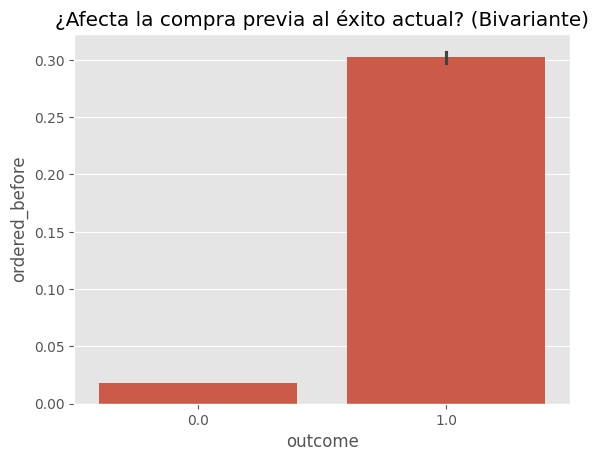

In [43]:
# Relación entre compra previa y éxito actual [cite: 13, 16]
sns.barplot(x='outcome', y='ordered_before', data=df_box)
plt.title('¿Afecta la compra previa al éxito actual? (Bivariante)')
plt.show()

* La probabilidad de compra de un usuario es mayor si ya ha comprado el prodcuto antes.
* La recurrencia es el motor de este e-comerce.

/home/usuari/.cache/pypoetry/virtualenvs/zrive-ds-aj6tOge6-py3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


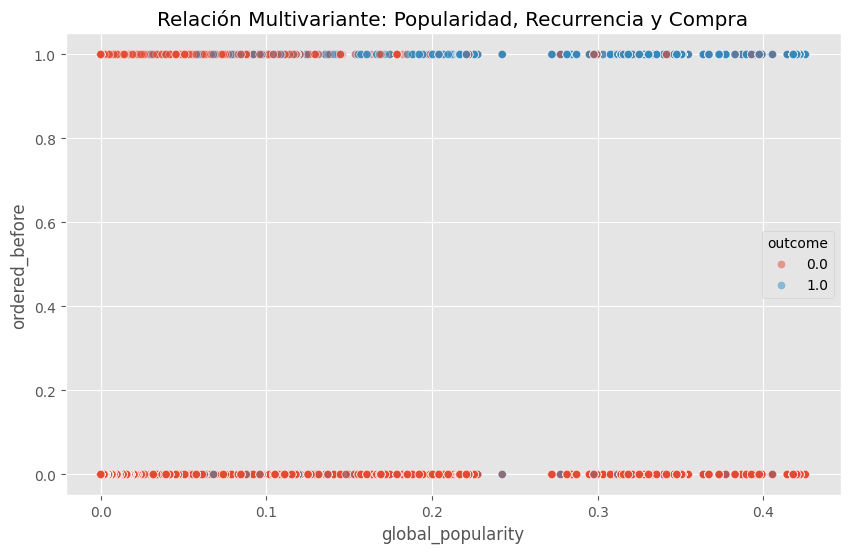

In [44]:
# Cruzamos: Popularidad Global vs Compras Previas vs Resultado Final
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_box, x='global_popularity', y='ordered_before', hue='outcome', alpha=0.5)
plt.title('Relación Multivariante: Popularidad, Recurrencia y Compra')
plt.show()

1. El predominio de la Recurrencia Individual
* Observación: Los puntos azules ($outcome=1.0$, es decir, compras con éxito) se concentran casi exclusivamente en la parte superior del gráfico, donde la variable ordered_before es igual a $1.0$.
* Insight: Esto confirma de forma visual que el factor más determinante para que un cliente añada un producto a su caja es que ya lo haya comprado anteriormente. La fidelidad individual pesa mucho más que las tendencias generales.
2. La Popularidad Global es un predictor débil
* Observación: En el eje horizontal (global_popularity), vemos que los puntos azules ($outcome=1.0$) están repartidos por todo el espectro, desde productos con baja popularidad hasta alta.
* Insight: Un producto no necesita ser "masivo" o muy popular a nivel global para ser comprado por un cliente específico; si ese cliente tiene un historial con el producto, lo comprará independientemente de lo que hagan los demás.

In [45]:
# Creamos una columna que combine si es regular y si ya ha comprado antes
df_box['fidelidad_total'] = df_box['set_as_regular'] * df_box['ordered_before']

# Comprobamos si esta nueva variable es "oro" para el modelo
print("Correlación de la nueva variable con el éxito:")
print(df_box[['fidelidad_total', 'outcome']].corr()['outcome'])

Correlación de la nueva variable con el éxito:
fidelidad_total    0.123755
outcome            1.000000
Name: outcome, dtype: float64


# Conclusion final
1. Calidad y Salud de los Datos 
* Integridad: Se identificó una desincronización del 14.45% entre los pedidos y el inventario, lo que sugiere la presencia de productos descatalogados o errores en el catálogo maestro. Aparte de MV también en variables relevante como precio en los productos de abandono, un 4,99% no disponian de ese dato. 
* Desequilibrio: El dataset presenta un sesgo crítico con solo un 1.15% de casos de éxito ($outcome=1$), lo que define este problema como uno de detección de minorías.
2. Patrones de Comportamiento 
* El Factor Fidelidad: La variable ordered_before es el predictor más potente (correlación de 0.21). La probabilidad de compra se triplica si el usuario ya ha adquirido el producto anteriormente.
* Indecisión y Abandono: Categorías como tins-packaged-foods presentan los mayores índices de abandono, a pesar de ser de las más populares, sugiriendo una alta sensibilidad al precio o variedad en este segmento.
3. Selección de Variables Críticas 
* Variables de Oro: Se recomienda priorizar ordered_before, abandoned_before y global_popularity para el entrenamiento del modelo.
* Variables a descartar: Variables como user_order_seq o IDs de usuario no aportan valor predictivo y deben ser eliminadas para evitar ruido.